# 🧠 Car Purchase Amount Prediction using Artificial Neural Networks (ANN)

## 📌 Project Overview

Artificial Neural Networks (ANN) are one of the most fundamental Deep Learning models inspired by the structure and functioning of the human brain. They are capable of learning complex relationships between input features and target values by adjusting weights through the process of backpropagation and gradient descent.

In this project, an ANN model is developed to predict the **Car Purchase Amount** based on customer information such as age, annual salary, credit card debt, and net worth.

The project demonstrates the complete Deep Learning workflow including data preprocessing, feature scaling, ANN model creation, training, evaluation, prediction, and model saving using TensorFlow and Keras.

---

## 🎯 Objective

- Understand the architecture of Artificial Neural Networks.
- Learn how ANN performs regression tasks.
- Build and train an ANN model using TensorFlow/Keras.
- Predict car purchase amounts for new customers.
- Gain hands-on experience with Deep Learning fundamentals.

In [34]:
#Importing the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [35]:
#Importing the dataset
df = pd.read_csv("Data/Car_Purchasing_Data.csv", encoding = 'ISO-8859-1')

In [36]:
#Visualizing the dataset
df.head(5)

,Customer Name,Customer e-mail,Country,Gender,Age,Annual Salary,Credit Card Debt,Net Worth,Car Purchase Amount
0,Martina Avila,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,Bulgaria,0,41.851720,62812.09301,11609.380910,238961.2505,35321.45877
1,Harlan Barnes,eu.dolor@diam.co.uk,Belize,0,40.870623,66646.89292,9572.957136,530973.9078,45115.52566
2,Naomi Rodriquez,vulputate.mauris.sagittis@ametconsectetueradip...,Algeria,1,43.152897,53798.55112,11160.355060,638467.1773,42925.70921
3,Jade Cunningham,malesuada@dignissim.com,Cook Islands,1,58.271369,79370.03798,14426.164850,548599.0524,67422.36313
4,Cedric Leach,felis.ullamcorper.viverra@egetmollislectus.net,Brazil,1,57.313749,59729.15130,5358.712177,560304.0671,55915.46248


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer Name        500 non-null    str    
 1   Customer e-mail      500 non-null    str    
 2   Country              500 non-null    str    
 3   Gender               500 non-null    int64  
 4   Age                  500 non-null    float64
 5   Annual Salary        500 non-null    float64
 6   Credit Card Debt     500 non-null    float64
 7   Net Worth            500 non-null    float64
 8   Car Purchase Amount  500 non-null    float64
dtypes: float64(5), int64(1), str(3)
memory usage: 60.0 KB


<Figure size 1000x500 with 0 Axes>

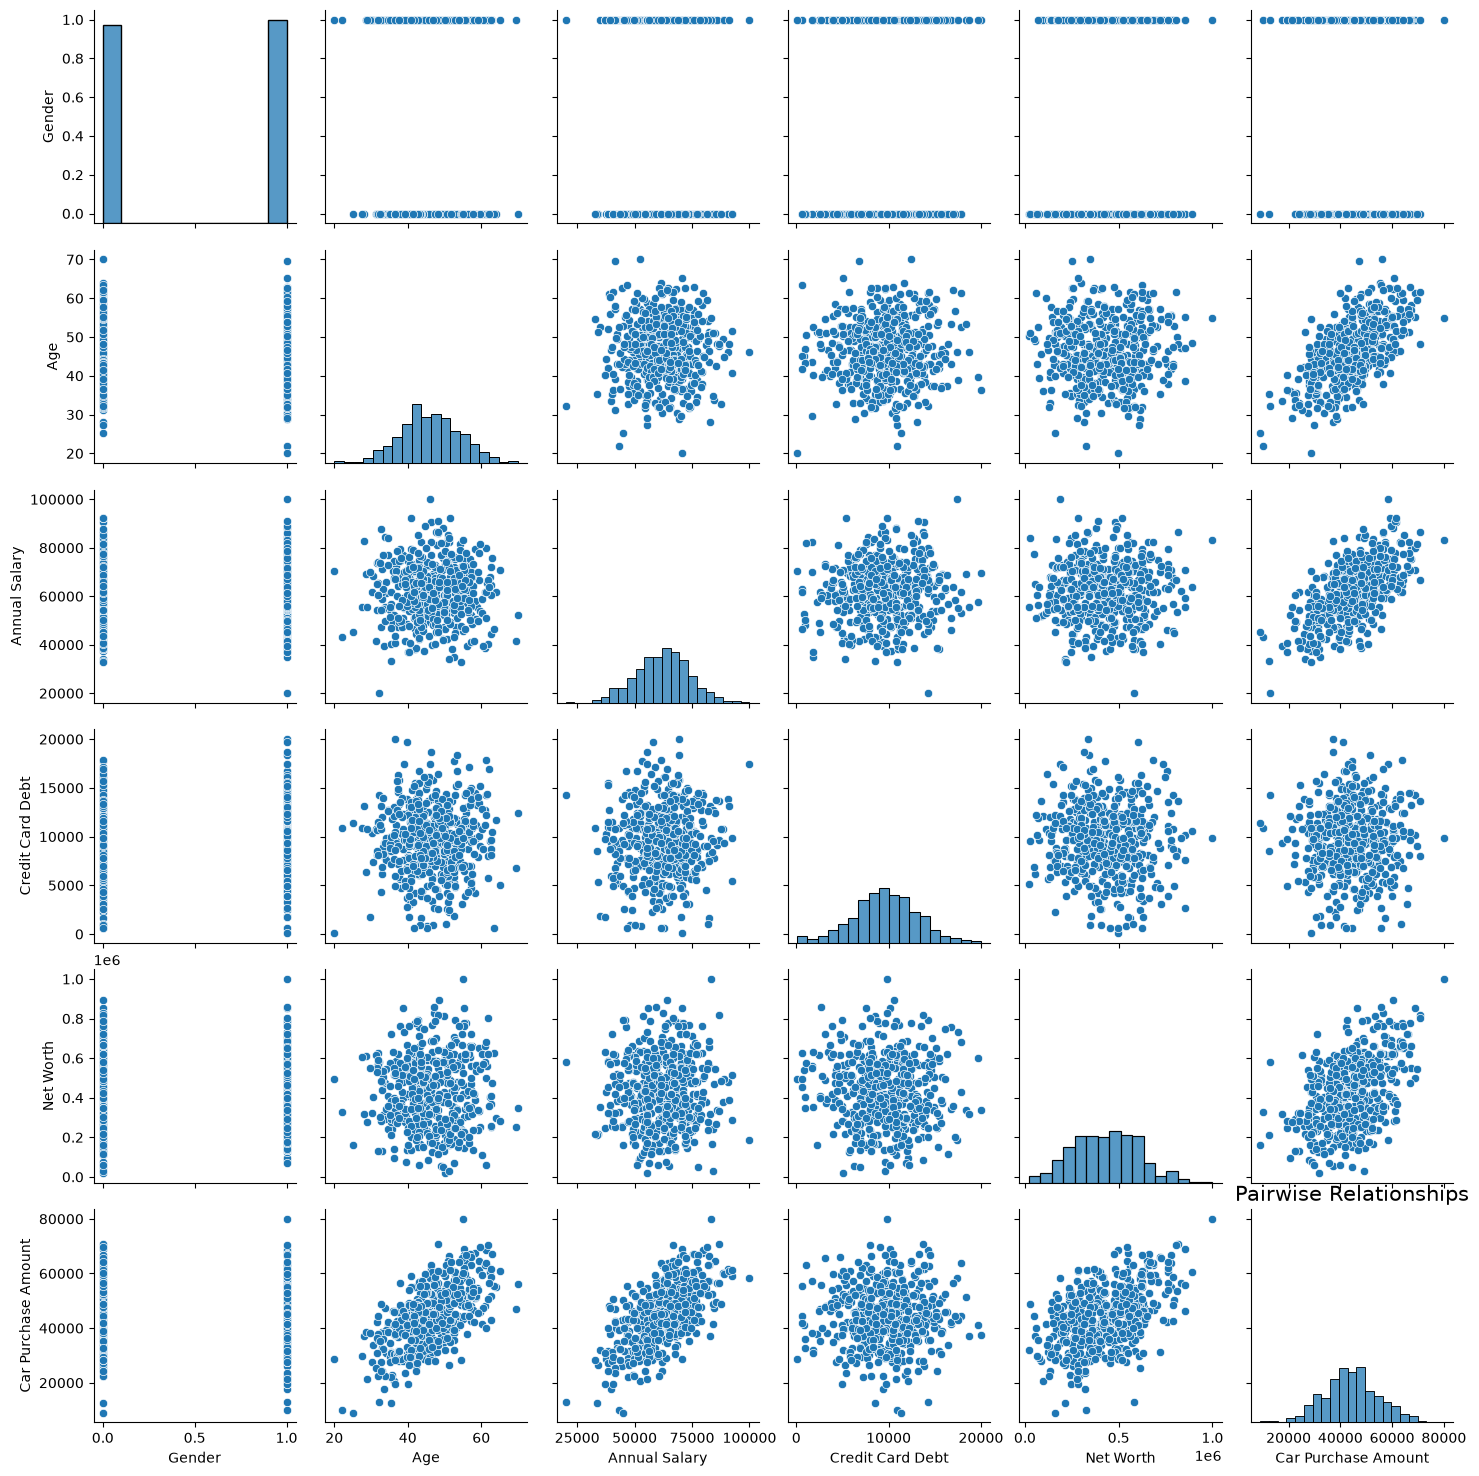

In [38]:
#Visualizing the pairwise relationships in the dataset
plt.figure(figsize=(10,5))
plot = sns.pairplot(df)
plt.title('Pairwise Relationships', fontsize=15)
plt.show()

In [39]:
#Preparing the data for training and testing
x = df.drop(['Customer Name', 'Customer e-mail', 'Country', 'Car Purchase Amount'], axis=1)
y = df['Car Purchase Amount']

In [40]:
#Data Preprocessing using MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()
x_scaled = x_scaler.fit_transform(x)
y = y.values.reshape(-1,1)
y_scaled = y_scaler.fit_transform(y)
print(x_scaled)
print(y_scaled)

[[0.         0.4370344  0.53515116 0.57836085 0.22342985]
 [0.         0.41741247 0.58308616 0.476028   0.52140195]
 [1.         0.46305795 0.42248189 0.55579674 0.63108896]
 ...
 [1.         0.67886994 0.61110973 0.52822145 0.75972584]
 [1.         0.78321017 0.37264988 0.69914746 0.3243129 ]
 [1.         0.53462305 0.51713347 0.46690159 0.45198622]]
[[0.37072477]
 [0.50866938]
 [0.47782689]
 [0.82285018]
 [0.66078116]
 [0.67059152]
 [0.28064374]
 [0.54133778]
 [0.54948752]
 [0.4111198 ]
 [0.70486638]
 [0.46885649]
 [0.27746526]
 [0.56702642]
 [0.57056385]
 [0.61996151]
 [0.46217916]
 [0.49157341]
 [0.50188722]
 [0.64545808]
 [0.59339372]
 [0.48453965]
 [0.53860366]
 [0.53007738]
 [0.50814651]
 [0.49841668]
 [0.3966416 ]
 [0.56467566]
 [0.6950749 ]
 [0.49287831]
 [0.12090943]
 [0.50211776]
 [0.80794216]
 [0.62661214]
 [0.43394857]
 [0.60017103]
 [0.42223485]
 [0.01538345]
 [0.37927499]
 [0.64539707]
 [0.51838974]
 [0.45869677]
 [0.26804521]
 [0.2650104 ]
 [0.84054134]
 [0.84401542]
 [

In [41]:
#Splitting the dataset into training and testing sets
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x_scaled, y_scaled, test_size=0.25, random_state=42)

In [42]:
#Building the Artificial Neural Network (ANN) model
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(25, input_dim=5, activation='relu'))
model.add(Dense(25, activation='relu'))
model.add(Dense(1, activation='linear'))
model.summary()

C:\Users\PCM\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 25)             │           150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 25)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 826 (3.23 KB)

 Trainable params: 826 (3.23 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
#Compiling and training the model
model.compile(loss='mean_squared_error', optimizer='adam')
epochs_hist = model.fit(x_train, y_train, epochs=20, batch_size=25, verbose=1, validation_split=0.2)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.4741 - val_loss: 0.2752
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2461 - val_loss: 0.1353
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1272 - val_loss: 0.0614
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0636 - val_loss: 0.0315
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0371 - val_loss: 0.0241
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0267 - val_loss: 0.0212
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0218 - val_loss: 0.0173
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0182 - val_loss: 0.0141
Epoch 9/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0156 - val_loss: 0.0127
Epoch 10/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0142 - val_loss: 0.0117
Epoch 11/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0132 - val_loss: 0.0108
Epoch 12/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0121 - val_l

In [44]:
#Visualizing the training history
epochs_hist.history.keys()

dict_keys(['loss', 'val_loss'])

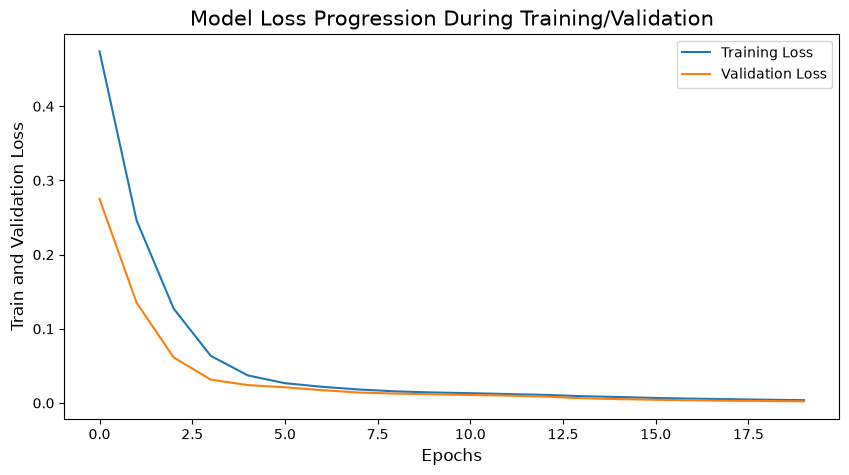

In [45]:
#Visualizing the training and validation loss
plt.figure(figsize=(10,5))
plt.plot(epochs_hist.history['loss'], label='Training Loss')
plt.plot(epochs_hist.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Progression During Training/Validation', fontsize=15)      
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Train and Validation Loss', fontsize=12)
plt.legend()
plt.show()

In [ ]:
#Making predictions using the trained model
x_test_sample = np.array([[1,0.44,0.62,0.764,0.2267]])
y_predicted = model.predict(x_test_sample)
y_predicted = y_scaler.inverse_transform(y_predicted)
print("Predicted Car Purchase Amount: ", y_predicted)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Predicted Car Purchase Amount:  [[36520.867]]


In [48]:
#Evaluating the model's performance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_actual = y_scaler.inverse_transform(y_test)
y_predict = y_scaler.inverse_transform(model.predict(x_test))

print("Mean Absolute Error :", mean_absolute_error(y_actual, y_predict))
print("Mean Squared Error  :", mean_squared_error(y_actual, y_predict))
print("R² Score            :", r2_score(y_actual, y_predict))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step 
Mean Absolute Error : 3005.4292675100014
Mean Squared Error  : 14380480.136880077
R² Score            : 0.86465684282318


# 🏁 Conclusion

In this project, an **Artificial Neural Network (ANN)** was developed to predict the **Car Purchase Amount** based on customer information such as gender, age, annual salary, credit card debt, and net worth.

The dataset was preprocessed by removing irrelevant features, scaling the input and output data using **MinMaxScaler**, and splitting the dataset into training and testing sets. A feedforward neural network was then built using **TensorFlow/Keras**, trained using the **Adam optimizer**, and optimized with the **Mean Squared Error (MSE)** loss function.

The trained model successfully learned the relationship between customer financial attributes and the car purchase amount. Predictions were generated for new customer data and converted back to the original scale using the inverse transformation.

This project provided practical experience in building, training, evaluating, and deploying a Deep Learning regression model, while strengthening the understanding of Artificial Neural Networks and their real-world applications.

# 📚 Key Learnings

Through this project, I learned:

- The fundamentals of Artificial Neural Networks (ANN).
- The architecture of a feedforward neural network.
- The role of neurons, weights, biases, and activation functions.
- The importance of feature scaling before training an ANN.
- How Gradient Descent and Backpropagation optimize neural networks.
- How to build and train an ANN using TensorFlow and Keras.
- How to evaluate a regression model using appropriate metrics.
- How to predict outcomes for new data and convert predictions back to their original scale.